# Krylov Solver: Magnetization Dynamics in Ising Chain

Author: Maximilian Meyer-Mölleringhof

We are looking at the functionality of the [Krylov solver in Qutip](https://qutip.readthedocs.io/en/stable/guide/dynamics/dynamics-krylov.html) here.
Especially when the Hilbert space gets large, using the Krylov subspace method can give great computational speed ups.
To us it, we provide the `krylovsolve` function an extra argument `krylov_dim` which determines the maximum subspace size it will construct.
By repeatedly constructing such a subspace, we iteratively solve the dynamics of our quantum system.
At the current state, the Krylov solver in QuTiP supports pure and mixed state as well as closed in (Lindblad like) open quantum systems.

In [66]:
from qutip import (
    krylovsolve,
    sesolve,
    mesolve,
    tensor,
    basis,
    sigmax,
    sigmam,
    sigmaz,
    qeye,
    about
)
import numpy as np
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt

%matplotlib inline

In this tutorial we are going to look at the magnetization dynamics of the transverse field Ising chain with the Hamiltonian

$\hat{H} = -J \sum_{i=1}^{N-1} \hat{\sigma}_z^i \hat{\sigma}_z^{i+1} - h \sum_{i=1}^{N} \hat{\sigma}_x^i$.

By tuning the coupling strength $J$ and the strength of the transverse field $h$, we will observe different behaviours of the magnetization

$\hat{M}_z = \sum_i \hat{\sigma}_z^i$

of the chain.
We encourage you to play with the parameters yourself and compare different parameter regimes such as $J < h$, $J = h$ and $J > h$.
Additionally, try increasing the chain length and playing witht the `krylov_dim` parameter to see when the algorithm becomes faster than the standard SE or ME solver.

In [67]:
def operator_chain(N, op):
    op_list = []
    for i in range(N):
        ops = [qeye(2)] * N
        ops[i] = op
        op_list.append(tensor(ops))
    return op_list

def ising_chain(N, J, h):
    sx_list = operator_chain(N, sigmax())
    sz_list = operator_chain(N, sigmaz())

    H = 0
    # Ising interaction
    for i in range(N - 1):
        H += -J * sz_list[i] * sz_list[i + 1]

    # transverse field
    for i in range(N):
        H += -h * sx_list[i]

    return H


In [68]:
N = 8           # number of spins
J = 1.0         # Ising coupling strength
h = 1.0         # transverse field strength

H = ising_chain(N, J, h)

In [69]:
tlist = np.linspace(0, 50, 500)
psi0 = tensor([basis(2, 0)] * N)  # initial state

sz_list = operator_chain(N, sigmaz())
Mz = sum(sz_list) / N  # magnetization

In [70]:
cl_res = krylovsolve(H, psi0, tlist, krylov_dim=25, e_ops=[Mz])

In [71]:
se_exact = sesolve(H, psi0, tlist, e_ops=[Mz])

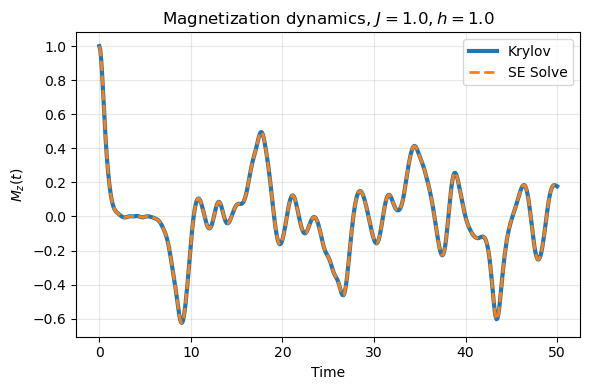

In [72]:
plt.figure(figsize=(6, 4))
plt.plot(tlist, cl_res.expect[0], lw=3, label="Krylov")
plt.plot(tlist, se_exact.expect[0], lw=2, linestyle='--', label="SE Solve")
plt.xlabel("Time")
plt.ylabel(r"$M_z(t)$")
plt.title(rf"Magnetization dynamics, $J = {J}, h = {h}$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

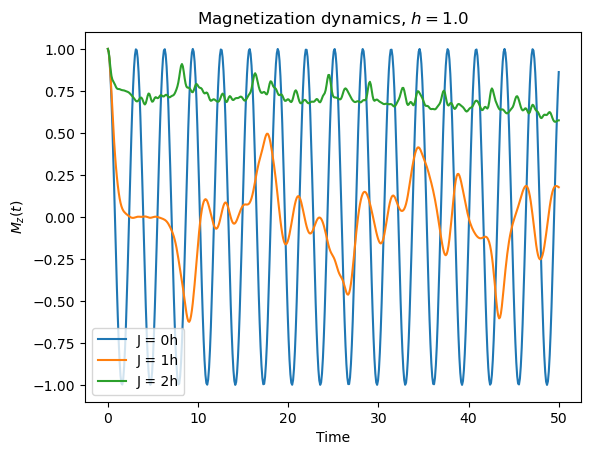

In [73]:
Js = [0, 1, 2] # factors

mags = np.zeros((len(Js), len(tlist)))
for i, j in enumerate(Js):
    H = ising_chain(N, j*h, h)
    res = krylovsolve(H, psi0, tlist, krylov_dim=25, e_ops=[Mz])
    mags[i] = res.expect[0]

for i, j in enumerate(Js):
    plt.plot(tlist, mags[i], label=f'J = {j}h')
plt.title(rf'Magnetization dynamics, $h = {h}$')
plt.ylabel(r'$M_z(t)$')
plt.xlabel('Time')
plt.legend()
plt.show()

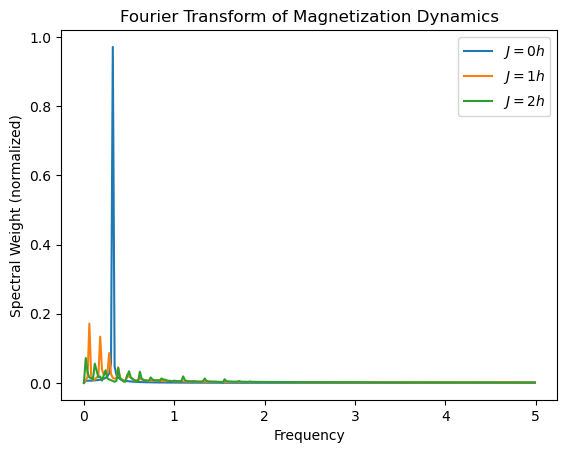

In [74]:
for i, m in enumerate(mags):
    omg = rfftfreq(len(m), tlist[1] - tlist[0])
    amp = rfft(m - np.mean(m))
    amp /= amp.sum()
    plt.plot(omg, np.abs(amp), label=rf'$J = {Js[i]}h$')

plt.title('Fourier Transform of Magnetization Dynamics')
plt.xlabel('Frequency')
plt.ylabel('Spectral Weight (normalized)')
plt.legend()
plt.show()

## Dynamics of a tilted Domain Wall

To make the dynamics in the chain a bit more interesting, let's look at the magnetization of the individual sites in the chain.
We will look at the evolution of a tiled domain wall which is modeled by the initial state

$| \psi_{\text{wall}} \rangle = | \uparrow \uparrow \rightarrow \downarrow \downarrow \rangle$.

In [75]:
# Smaller chain to save some time
N = 5
J = 1.0
h = 0.5

H = ising_chain(N, J, h)

sz_list = operator_chain(N, sigmaz())
Mz = sum(sz_list) / N

# Domain wall as initial state
pls = (basis(2, 0) + basis(2, 1)) / np.sqrt(2)
wall = tensor([basis(2, 0)]*(N//2) + [pls] + [basis(2, 1)]*(N//2))

In [76]:
res_wall = krylovsolve(H, wall, tlist, krylov_dim=30, e_ops=sz_list)

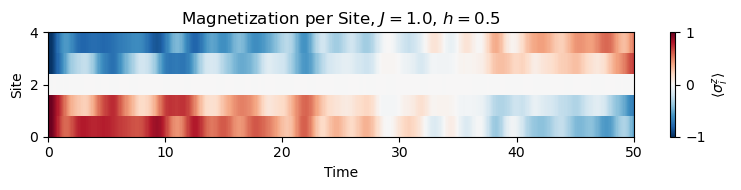

In [77]:
plt.figure(figsize=(8,2))
plt.imshow(res_wall.expect, origin="lower", aspect="auto", extent=[tlist[0], tlist[-1], 0, N-1], cmap="RdBu_r", vmin=-1, vmax=1, interpolation='none')

plt.title(rf"Magnetization per Site, $J = {J}$, $h = {h}$")
plt.xlabel("Time")
plt.ylabel("Site")
plt.colorbar(label=r"$\langle\sigma_i^z\rangle$")
plt.tight_layout()
plt.show()

We see that the magnetization oscillates and as time progesses even swaps places.
Naturally, this behavior is highly dependent on the parameteres $J$ and $h$, so we encourage you to play around with these.

## Relaxation Term

Lastly, we want to show the usage of the Krylov solver for open (Lindblad like) quantum systems.
For that we add a collapse operator to the description of our system
$\sqrt{\gamma} \sigma_-$
where $\gamma$ gives the strength of the relaxation.

In [78]:
gamma = 2
c_ops = tensor([np.sqrt(gamma) * sigmam()] * N)

The Krylov solver can speed up computations significantly, especially at larger dimensions.
However, a smart choice of the Kyrlov dimension is critical.
Too small and too large will both render the algorithm inefficient.
Although there is no definite *optimal* dimension, a generally good starting point is $K_{\text{dim}} \lesssim \sqrt{\text{dim}H}$ where $H$ can be a Hamiltonian or Liouvillian.

In [85]:
op_res= krylovsolve(H, wall, tlist, krylov_dim=20, c_ops=c_ops, e_ops=[Mz] + sz_list)

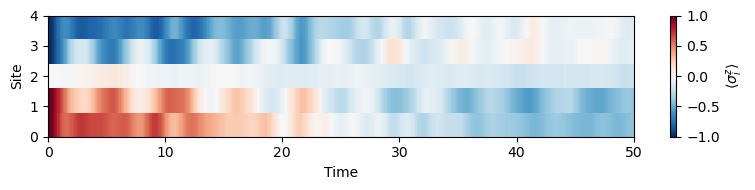

In [86]:
plt.figure(figsize=(8,2))
plt.imshow(op_res.expect[1:], origin="lower", aspect="auto", extent=[tlist[0], tlist[-1], 0, N-1], cmap="RdBu_r", vmin=-1, vmax=1, interpolation='none')

plt.xlabel("Time")
plt.ylabel("Site")
plt.colorbar(label=r"$\langle\sigma_i^z\rangle$")
plt.tight_layout()
plt.show()

Same as before, we observe oscillations of the magnetization, however a general trend towards the $| \downarrow \downarrow ... \rangle$ is visible.
This is of course enforced by the collapse operator that we introduced in this section, leading the system to relax.
To emphasis this effect even more, we show below the total magnetization compared with the results from ME Solve.
Observe how the osciallations are still present, but the overall trend is towards downward magnetization.

In [81]:
me_exact = mesolve(H, wall, tlist, c_ops=c_ops, e_ops=[Mz])

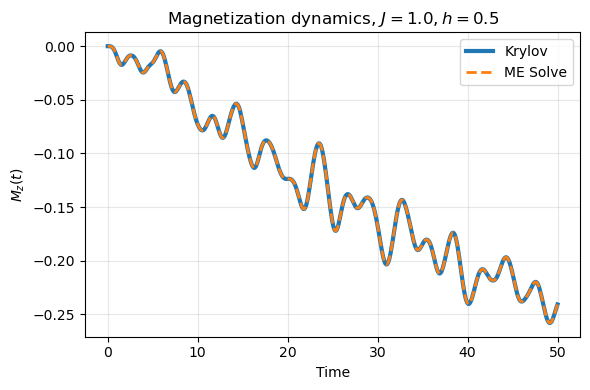

In [87]:
plt.figure(figsize=(6, 4))
plt.plot(tlist, op_res.expect[0], lw=3, label="Krylov")
plt.plot(tlist, me_exact.expect[0], lw=2, linestyle='--', label="ME Solve")
plt.xlabel("Time")
plt.ylabel(r"$M_z(t)$")
plt.title(f"Magnetization dynamics, $J = {J}, h = {h}$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

## About

In [83]:
about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.3.0
Numpy Version:      2.2.5
Scipy Version:      1.16.1
Cython Version:     3.1.3
Matplotlib Version: 3.10.0
Python Version:     3.13.5
Number of CPUs:     10
BLAS Info:          openblas
INTEL MKL Ext:      None
Platform Info:      Darwin (arm64)
Installation path:  /opt/homebrew/Caskroom/miniconda/base/envs/my-qutip/lib/python3.13/site-packages/qutip

Installed QuTiP family packages
-------------------------------

qutip-qip: 0.4.1


## Testing

In [89]:
np.testing.assert_allclose(cl_res.expect[0], se_exact.expect[0], atol=0.01, rtol=0)
np.testing.assert_allclose(op_res.expect[0], me_exact.expect[0], atol=0.01, rtol=0)